=== متوسط ساعات المشاهدة حسب الأيام (تحديد أوقات الذروة) ===


,day_name,Total_watch_time_in_houres
0,Fri (الجمعة),793.924330
1,Mon (الإثنين),790.172377
3,Tue (الثلاثاء),785.231912
2,Thu (الخميس),767.930294
4,Wed (الأربعاء),766.280458


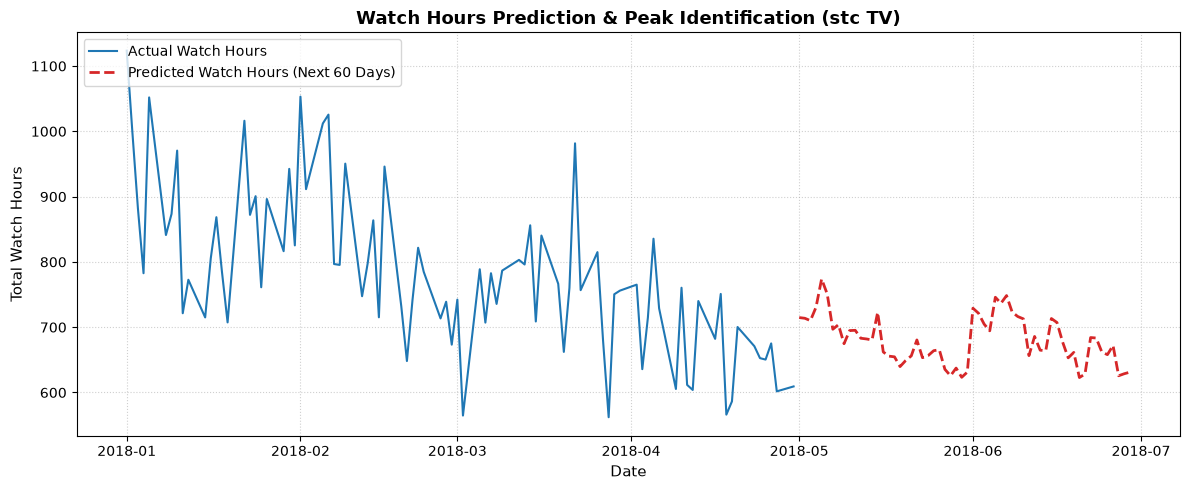

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from datetime import timedelta

%matplotlib inline

file_path = 'stc TV Data Set_T2.xlsx'
df = pd.read_excel(file_path)

df['date_'] = pd.to_datetime(df['date_'])
daily_data = df.groupby('date_')['Total_watch_time_in_houres'].sum().reset_index()
daily_data = daily_data.sort_values('date_')

daily_data['day_of_week'] = daily_data['date_'].dt.dayofweek
daily_data['day_of_month'] = daily_data['date_'].dt.day
daily_data['month'] = daily_data['date_'].dt.month
daily_data['is_weekend'] = daily_data['day_of_week'].isin([4, 5]).astype(int)

X = daily_data[['day_of_week', 'day_of_month', 'month', 'is_weekend']]
y = daily_data['Total_watch_time_in_houres']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

last_date = daily_data['date_'].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 61)]
future_df = pd.DataFrame({'date_': future_dates})

future_df['day_of_week'] = future_df['date_'].dt.dayofweek
future_df['day_of_month'] = future_df['date_'].dt.day
future_df['month'] = future_df['date_'].dt.month
future_df['is_weekend'] = future_df['day_of_week'].isin([4, 5]).astype(int)

future_df['Predicted_Watch_Hours'] = model.predict(future_df[['day_of_week', 'day_of_month', 'month', 'is_weekend']])

days_map = {0: 'Mon (الإثنين)', 1: 'Tue (الثلاثاء)', 2: 'Wed (الأربعاء)', 3: 'Thu (الخميس)', 4: 'Fri (الجمعة)', 5: 'Sat (السبت)', 6: 'Sun (الأحد)'}
daily_data['day_name'] = daily_data['day_of_week'].map(days_map)
peak_days = daily_data.groupby('day_name')['Total_watch_time_in_houres'].mean().reset_index()

print("=========================================================")
print("=== متوسط ساعات المشاهدة حسب الأيام (تحديد أوقات الذروة) ===")
print("=========================================================")
display(peak_days.sort_values(by='Total_watch_time_in_houres', ascending=False))

plt.figure(figsize=(12, 5))

plt.plot(daily_data['date_'], daily_data['Total_watch_time_in_houres'], label='Actual Watch Hours', color='#1f77b4', linewidth=1.5)
plt.plot(future_df['date_'], future_df['Predicted_Watch_Hours'], label='Predicted Watch Hours (Next 60 Days)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Watch Hours Prediction & Peak Identification (stc TV)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Total Watch Hours', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()